In [29]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import seaborn as sns

In [30]:
df = pd.read_csv("Iris.csv")

In [31]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
df.describe()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [33]:
df = df.drop("Id", axis=1)


In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [35]:
df.isnull().sum()


SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [36]:
X = pd.DataFrame(df.iloc[:,1:-1])
y_text = pd.DataFrame(df.iloc[:,-1])

<Axes: xlabel='Species', ylabel='count'>

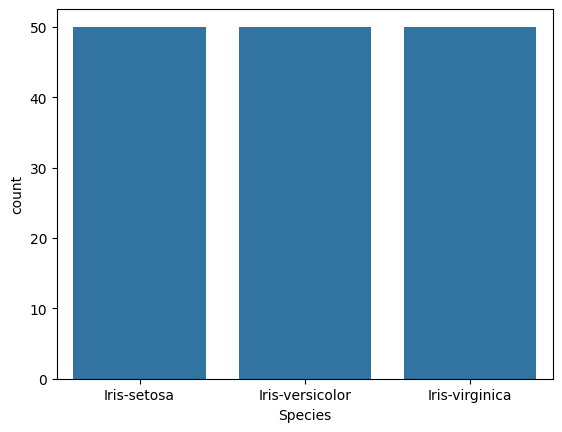

In [37]:
sns.countplot(data=df, x="Species")

In [38]:
# from sklearn import preprocessing

# le = preprocessing.LabelEncoder()

# # y_target = pd.DataFrame(y_text["Species"])
# y_target = np.transpose(y_text)
# y_target
# y_enc = le.fit_transform(y_target)

In [39]:
from sklearn import preprocessing

le = preprocessing.LabelEncoder()

y_enc = le.fit_transform(y_text.iloc[:,0])

y = pd.DataFrame(y_enc)

print(le.classes_)

y.head(150)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,0
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [40]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
from sklearn import svm

clf = svm.SVC(kernel="linear")
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

from sklearn import metrics
confusion_mat = metrics.confusion_matrix(y_pred, y_test)

print("Confusion matrix")
print(confusion_mat)

print("Accuracy =", metrics.accuracy_score(y_test, y_pred))
print("F1 score =", metrics.f1_score(y_test, y_pred, average="macro"))

Confusion matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy = 1.0
F1 score = 1.0


c:\Users\LENOVO\anaconda3\envs\mdm\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [42]:
from sklearn import svm

clf = svm.SVC(kernel="rbf")
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

from sklearn import metrics
confusion_mat = metrics.confusion_matrix(y_pred, y_test)

print("Confusion matrix")
print(confusion_mat)

print("Accuracy =", metrics.accuracy_score(y_test, y_pred))
print("F1 score =", metrics.f1_score(y_test, y_pred, average="micro"))

Confusion matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy = 1.0
F1 score = 1.0


c:\Users\LENOVO\anaconda3\envs\mdm\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
